In [1]:
from simple_neural_mpc.robots import Unicycle
from simple_neural_mpc.neural_modeling.dataset import UnicycleDataset
from simple_neural_mpc.neural_modeling.dataset.datamodule import Datamodule
from simple_neural_mpc.utils import project_root
import numpy as np
from simple_neural_mpc.config.neural_config import DatasetConfig
np.set_printoptions(precision=3, suppress=True)

robot = Unicycle()
dataset = None if DatasetConfig.load_data else UnicycleDataset.generate_trajectory_data(robot)
datamodule = Datamodule(dataset, savedpath=f'{project_root()}/data/{DatasetConfig.name}')
print(datamodule.train_data.data.shape)
print(datamodule.train_data.labels.shape)

DATA SAVED!
torch.Size([800, 100, 5])
torch.Size([800, 100, 3])


In [2]:
from simple_neural_mpc.neural_modeling.learner.mlp_learner import MlpLearner
from simple_neural_mpc.neural_modeling.learner.mlp_traj_learner import MlpTrajLearner
from simple_neural_mpc.neural_modeling.learner.trainer import Trainer
from simple_neural_mpc.config.neural_config import TrainerConfig

TrainerConfig.wandb_project = "neural_mpc_mlp"
learner = MlpTrajLearner(robot)
trainer = Trainer()
trainer.fit(learner, datamodule)

wandb: Currently logged in as: neverorfrog (neverorfrog-sapienza). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/neverorfrog/.netrc
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/neverorfrog/code/simple_neural_mpc/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.

  | Name | Type    | Params | Mode 
-----------------------------------------
0 | mlp  | MLP     | 17.7 K | train
1 | mse  | MSELoss | 0      | train
-----------------------------------------
17.7 K    Trainable params
0         Non-trainable params
17.7 K    Total params
0.071     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 800/800 [00:16<00:00, 48.12it/s, v_num=z20z]

Metric val/loss improved. New best score: 0.081


Epoch 1: 100%|██████████| 800/800 [00:16<00:00, 47.18it/s, v_num=z20z]

...

Epoch 19: 100%|██████████| 800/800 [00:18<00:00, 42.28it/s, v_num=z20z]

Metric val/loss improved by 0.000 >= min_delta = 0.0001. New best score: 0.000


Epoch 29: 100%|██████████| 800/800 [00:17<00:00, 45.50it/s, v_num=z20z]

Monitored metric val/loss did not improve in the last 10 records. Best score: 0.000. Signaling Trainer to stop.


Epoch 29: 100%|██████████| 800/800 [00:17<00:00, 45.49it/s, v_num=z20z]


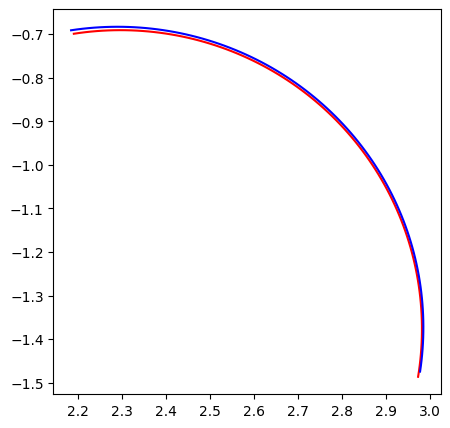

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
test_data = datamodule.test_data
predictions = learner.inference(test_data)

random_idx = np.random.randint(0, test_data.data.shape[0])
random_traj = test_data.data[random_idx]

random_prediction = predictions[random_idx].detach().numpy()

ax.plot(random_traj[:, 0], random_traj[:, 1], 'r')
ax.plot(random_prediction[:, 0], random_prediction[:, 1], 'b')